In [41]:
import bk_tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from bk_tools import BASE_DIR

# Import all necessary libraries for data manipulation, visualization and deep learning.

In [42]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: []


In [43]:
# Prepare the data table using the custom function from bk_tools and display its information.
df = bk_tools.prepare_data_table()
df.info()
df["class"].unique()

DataFrame shape: (7909, 8)
DataFrame columns: ['patient_id', 'file_id', 'example', 'class', 'year', 'zoom', 'file_path', 'is_malign']
Parsed files: 7909
Failed files: 0
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


<StringArray>
['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']
Length: 8, dtype: str

In [44]:
from sklearn.model_selection import train_test_split


def patient_stratified_split_for_pytorch(
    df,
    chosen_zoom=200,
    temp_size=0.2,
    seed=42,
    expected_classes=None,
    n_trials=250,
    require_full_test_coverage=True,
    require_full_val_coverage=False,
):
    """
    Leakage-safe patient-level split with class-coverage optimization.

    Strategy:
    - Remove multi-class patients.
    - Try multiple random stratified splits.
    - Prefer splits with broad val/test class coverage.
    - Enforce hard-constraints when possible.
    """
    if chosen_zoom is not None:
        zoom_str = str(chosen_zoom).replace("x", "").replace("X", "")
        df_work = df[df["zoom"].astype(str).str.contains(zoom_str, na=False)].copy()
    else:
        df_work = df.copy()

    if df_work.empty:
        raise ValueError("No samples left after zoom filtering.")

    patient_nclass = df_work.groupby("patient_id")["class"].nunique()
    bad_patients = patient_nclass[patient_nclass > 1].index
    if len(bad_patients) > 0:
        print(f"Removing {len(bad_patients)} multi-class patients.")
        df_work = df_work[~df_work["patient_id"].isin(bad_patients)].copy()

    if df_work.empty:
        raise ValueError("No samples left after removing multi-class patients.")

    patient_df = df_work[["patient_id", "class"]].drop_duplicates().reset_index(drop=True)

    if expected_classes is None:
        target_classes = sorted(df_work["class"].unique().tolist())
    else:
        target_classes = sorted(expected_classes)
    target_class_set = set(target_classes)

    class_patient_counts = patient_df["class"].value_counts().to_dict()
    impossible_test = sorted([c for c in target_classes if class_patient_counts.get(c, 0) < 2])
    impossible_val = sorted([c for c in target_classes if class_patient_counts.get(c, 0) < 3])

    if require_full_test_coverage and impossible_test:
        print("[WARN] Full test coverage impossible for classes (need >=2 patients):", impossible_test)
    if require_full_val_coverage and impossible_val:
        print("[WARN] Full val coverage impossible for classes (need >=3 patients):", impossible_val)

    best = None
    best_score = -1

    for trial_seed in range(seed, seed + n_trials):
        class_counts = patient_df["class"].value_counts()
        stratify_first = patient_df["class"] if class_counts.min() >= 2 else None

        try:
            train_patients, temp_patients = train_test_split(
                patient_df["patient_id"].values,
                test_size=temp_size,
                random_state=trial_seed,
                stratify=stratify_first,
                shuffle=True,
            )
        except ValueError:
            continue

        temp_df = patient_df[patient_df["patient_id"].isin(temp_patients)].copy()
        if len(temp_df) < 2:
            continue

        temp_counts = temp_df["class"].value_counts()
        stratify_second = temp_df["class"] if temp_counts.min() >= 2 else None

        try:
            val_patients, test_patients = train_test_split(
                temp_df["patient_id"].values,
                test_size=0.5,
                random_state=trial_seed,
                stratify=stratify_second,
                shuffle=True,
            )
        except ValueError:
            continue

        train_df_tmp = df_work[df_work["patient_id"].isin(train_patients)].reset_index(drop=True)
        val_df_tmp = df_work[df_work["patient_id"].isin(val_patients)].reset_index(drop=True)
        test_df_tmp = df_work[df_work["patient_id"].isin(test_patients)].reset_index(drop=True)

        tr_p = set(train_df_tmp["patient_id"].unique())
        va_p = set(val_df_tmp["patient_id"].unique())
        te_p = set(test_df_tmp["patient_id"].unique())
        if (tr_p & va_p) or (tr_p & te_p) or (va_p & te_p):
            continue

        train_cls = set(train_df_tmp["class"].unique())
        val_cls = set(val_df_tmp["class"].unique())
        test_cls = set(test_df_tmp["class"].unique())

        valid = True
        if require_full_test_coverage:
            feasible_test_set = target_class_set - set(impossible_test)
            valid = feasible_test_set.issubset(test_cls)
        if valid and require_full_val_coverage:
            feasible_val_set = target_class_set - set(impossible_val)
            valid = feasible_val_set.issubset(val_cls)
        if not valid:
            continue

        score = (
            len(train_cls) * 1
            + len(val_cls) * 4
            + len(test_cls) * 5
            + len(val_cls & target_class_set) * 4
            + len(test_cls & target_class_set) * 5
        )

        if target_class_set.issubset(test_cls):
            score += 200
        if target_class_set.issubset(val_cls):
            score += 120

        if score > best_score:
            best_score = score
            best = (train_df_tmp, val_df_tmp, test_df_tmp)

    if best is None:
        raise ValueError("No valid leakage-safe split found under current hard constraints.")

    train_df, val_df, test_df = best

    class_to_idx = {c: i for i, c in enumerate(target_classes)}

    train_df = train_df[train_df["class"].isin(class_to_idx)].copy()
    val_df = val_df[val_df["class"].isin(class_to_idx)].copy()
    test_df = test_df[test_df["class"].isin(class_to_idx)].copy()

    train_df["label"] = train_df["class"].map(class_to_idx).astype(int)
    val_df["label"] = val_df["class"].map(class_to_idx).astype(int)
    test_df["label"] = test_df["class"].map(class_to_idx).astype(int)

    tr_p = set(train_df["patient_id"].unique())
    va_p = set(val_df["patient_id"].unique())
    te_p = set(test_df["patient_id"].unique())
    if (tr_p & va_p) or (tr_p & te_p) or (va_p & te_p):
        raise ValueError("Data leakage detected: patient overlap across splits.")

    print("Split sizes (images):", len(train_df), len(val_df), len(test_df))
    print("Patients:", len(tr_p), len(va_p), len(te_p))
    print("Leakage check passed: no patient overlap.")
    print("Class mapping:", class_to_idx)

    print("\nClass coverage:")
    print("Train:", sorted(train_df["class"].unique().tolist()))
    print("Val  :", sorted(val_df["class"].unique().tolist()))
    print("Test :", sorted(test_df["class"].unique().tolist()))

    return train_df, val_df, test_df, class_to_idx

In [45]:
EXPECTED_CLASSES = ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']
EXPECTED_SET = set(EXPECTED_CLASSES)

# Step 1: Strict single-zoom split. Step 2: fallback to all zooms when needed.
train_df, val_df, test_df, class_to_idx = patient_stratified_split_for_pytorch(
    df=df,
    chosen_zoom=400,
    temp_size=0.4,
    seed=42,
    expected_classes=EXPECTED_CLASSES,
    n_trials=1200,
    require_full_test_coverage=True,
    require_full_val_coverage=False,
)

val_cov = set(val_df['class'].unique().tolist())
test_cov = set(test_df['class'].unique().tolist())

if test_cov != EXPECTED_SET:
    print("\n[INFO] Test coverage incomplete at zoom=200. Retrying with all zoom levels...")
    train_df, val_df, test_df, class_to_idx = patient_stratified_split_for_pytorch(
        df=df,
        chosen_zoom=None,
        temp_size=0.4,
        seed=42,
        expected_classes=EXPECTED_CLASSES,
        n_trials=1800,
        require_full_test_coverage=True,
        require_full_val_coverage=False,
    )

print("\nTrain class counts:\n", train_df['class'].value_counts())
print("\nVal class counts:\n", val_df['class'].value_counts())
print("\nTest class counts:\n", test_df['class'].value_counts())

Removing 1 multi-class patients.
Split sizes (images): 1075 359 334
Patients: 48 16 16
Leakage check passed: no patient overlap.
Class mapping: {'A': 0, 'DC': 1, 'F': 2, 'LC': 3, 'MC': 4, 'PC': 5, 'PT': 6, 'TA': 7}

Class coverage:
Train: ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']
Val  : ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'TA']
Test : ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']

Train class counts:
 class
DC    445
F     140
PT     98
MC     93
PC     90
TA     84
LC     65
A      60
Name: count, dtype: int64

Val class counts:
 class
DC    197
MC     50
PC     35
LC     29
A      17
F      16
TA     15
Name: count, dtype: int64

Test class counts:
 class
DC    120
F      81
TA     31
A      29
MC     26
LC     17
PT     17
PC     13
Name: count, dtype: int64


In [46]:
import os
import platform
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE = 224
BATCH_SIZE = 32

# Jupyter + macOS spawn pickling issues are common with num_workers>0.
if platform.system() == "Darwin":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, os.cpu_count() or 2)

PIN_MEMORY = torch.cuda.is_available()

# ImageNet normalization is suitable for pretrained backbones.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Class-conditional augmentation setup.
MINORITY_CLASS_NAMES = {"PT", "MC", "PC"}

train_transform_common = transforms.Compose([
    transforms.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.92, 1.08),
        interpolation=transforms.InterpolationMode.BICUBIC,
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=8, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.ColorJitter(brightness=0.08, contrast=0.10, saturation=0.07, hue=0.012),
    transforms.RandomApply([transforms.RandomAdjustSharpness(sharpness_factor=1.4)], p=0.20),
    transforms.RandomApply([transforms.RandomAutocontrast()], p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.01, 0.06), ratio=(0.6, 1.6), value="random"),
])

# Slightly stronger variant for minority classes.
train_transform_minor = transforms.Compose([
    transforms.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.80, 1.0),
        ratio=(0.88, 1.12),
        interpolation=transforms.InterpolationMode.BICUBIC,
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=12, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.06),
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.ColorJitter(brightness=0.12, contrast=0.14, saturation=0.10, hue=0.015),
    transforms.RandomApply([transforms.RandomAdjustSharpness(sharpness_factor=1.8)], p=0.30),
    transforms.RandomApply([transforms.RandomAutocontrast()], p=0.25),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.9))
    ], p=0.20),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.01, 0.10), ratio=(0.5, 2.0), value="random"),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BICUBIC, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms are ready.")
print("NUM_WORKERS:", NUM_WORKERS, "| PIN_MEMORY:", PIN_MEMORY)
print("Minority classes for stronger augmentation:", sorted(MINORITY_CLASS_NAMES))

Transforms are ready.
NUM_WORKERS: 0 | PIN_MEMORY: False
Minority classes for stronger augmentation: ['MC', 'PC', 'PT']


In [47]:
class BreakHisTorchDataset(Dataset):
    def __init__(self, dataframe, transform=None, minority_transform=None, minority_class_names=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.minority_transform = minority_transform
        self.minority_class_names = set(minority_class_names or [])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["file_path"]).convert("RGB")
        label = int(row["label"])
        class_name = str(row["class"])

        if self.minority_transform is not None and class_name in self.minority_class_names:
            image = self.minority_transform(image)
        elif self.transform is not None:
            image = self.transform(image)

        return image, label


class BalancedBatchSampler:
    """Create batches with a fixed minority-majority ratio and critical-class coverage."""

    def __init__(self, labels, minority_indices, batch_size=32, minority_per_batch=8, seed=42, critical_class_ids=None, critical_per_batch=1):
        self.labels = np.asarray(labels)
        self.minority_indices = np.asarray(minority_indices, dtype=int)
        self.batch_size = int(batch_size)
        self.minority_per_batch = int(minority_per_batch)
        self.majority_per_batch = self.batch_size - self.minority_per_batch
        self.seed = int(seed)

        all_idx = np.arange(len(self.labels))
        self.majority_indices = np.setdiff1d(all_idx, self.minority_indices)

        if self.minority_per_batch <= 0 or self.majority_per_batch <= 0:
            raise ValueError("minority_per_batch must be between 1 and batch_size-1.")
        if len(self.minority_indices) == 0 or len(self.majority_indices) == 0:
            raise ValueError("Need both minority and majority samples for balanced batches.")

        # Keep per-minority-class pools so each hard class can appear in most batches.
        self.minority_groups = {}
        for cls_id in np.unique(self.labels[self.minority_indices]):
            cls_pool = self.minority_indices[self.labels[self.minority_indices] == cls_id]
            if len(cls_pool) > 0:
                self.minority_groups[int(cls_id)] = cls_pool

        # Rarer minority classes get higher probability for the remaining minority slots.
        cls_counts = {
            cls_id: max(1, len(pool))
            for cls_id, pool in self.minority_groups.items()
        }
        minority_weights = np.array([1.0 / cls_counts[int(self.labels[idx])] for idx in self.minority_indices], dtype=np.float64)
        self.minority_probs = minority_weights / (minority_weights.sum() + 1e-12)

        self.critical_class_ids = [int(c) for c in (critical_class_ids or []) if int(c) in self.minority_groups]
        self.critical_per_batch = max(0, min(int(critical_per_batch), self.minority_per_batch))
        self.critical_groups = {c: self.minority_groups[c] for c in self.critical_class_ids}

    def __iter__(self):
        rng = np.random.default_rng(self.seed)
        n_batches = len(self)

        for _ in range(n_batches):
            per_group_samples = []
            selected_critical = []

            if self.critical_per_batch > 0 and self.critical_groups:
                crit_ids = list(self.critical_groups.keys())
                rng.shuffle(crit_ids)
                for cls_id in crit_ids[: min(self.critical_per_batch, len(crit_ids))]:
                    pool = self.critical_groups[cls_id]
                    per_group_samples.append(int(rng.choice(pool, size=1, replace=True)[0]))
                    selected_critical.append(cls_id)

            group_ids = [g for g in self.minority_groups.keys() if g not in selected_critical]
            rng.shuffle(group_ids)

            # First pass: at most one sample per minority class.
            remaining_first_pass = self.minority_per_batch - len(per_group_samples)
            for cls_id in group_ids[: min(remaining_first_pass, len(group_ids))]:
                pool = self.minority_groups[cls_id]
                per_group_samples.append(int(rng.choice(pool, size=1, replace=True)[0]))

            remaining = self.minority_per_batch - len(per_group_samples)
            if remaining > 0:
                extra = rng.choice(
                    self.minority_indices,
                    size=remaining,
                    replace=True,
                    p=self.minority_probs,
                ).tolist()
                min_idx = np.array(per_group_samples + extra, dtype=int)
            else:
                min_idx = np.array(per_group_samples[: self.minority_per_batch], dtype=int)
            maj_idx = rng.choice(self.majority_indices, size=self.majority_per_batch, replace=True)
            batch = np.concatenate([min_idx, maj_idx])
            rng.shuffle(batch)
            yield batch.tolist()

    def __len__(self):
        return max(1, len(self.labels) // self.batch_size)


train_dataset = BreakHisTorchDataset(
    train_df,
    transform=train_transform_common,
    minority_transform=train_transform_minor,
    minority_class_names=MINORITY_CLASS_NAMES,
)
val_dataset = BreakHisTorchDataset(val_df, transform=val_test_transform)
test_dataset = BreakHisTorchDataset(test_df, transform=val_test_transform)

# Keep this toggle for quick A/B.
USE_BALANCED_BATCH_SAMPLER = True

train_labels = train_df["label"].to_numpy()
class_counts = np.bincount(train_labels, minlength=len(class_to_idx))

minority_label_ids = [class_to_idx[c] for c in MINORITY_CLASS_NAMES if c in class_to_idx]
minority_indices = np.where(np.isin(train_labels, minority_label_ids))[0]
critical_label_ids = [class_to_idx[c] for c in ("PT", "MC", "PC") if c in class_to_idx]

if USE_BALANCED_BATCH_SAMPLER:
    batch_sampler = BalancedBatchSampler(
        labels=train_labels,
        minority_indices=minority_indices,
        batch_size=BATCH_SIZE,
        minority_per_batch=max(6, BATCH_SIZE // 4),
        seed=42,
        critical_class_ids=critical_label_ids,
        critical_per_batch=2,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_sampler=batch_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    sampler = None
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    sampler = None

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

print("Datasets and DataLoaders are ready.")
print("Train / Val / Test images:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Class counts (train):", class_counts.tolist())
print("USE_BALANCED_BATCH_SAMPLER:", USE_BALANCED_BATCH_SAMPLER)
print("Minority labels:", minority_label_ids, "| minority samples:", int(len(minority_indices)))
print("Critical labels:", critical_label_ids)

Datasets and DataLoaders are ready.
Train / Val / Test images: 1075 359 334
Class counts (train): [60, 445, 140, 65, 93, 90, 98, 84]
USE_BALANCED_BATCH_SAMPLER: True
Minority labels: [6, 5, 4] | minority samples: 281
Critical labels: [6, 4, 5]


In [48]:
# Quick sanity check: one batch shape and label distribution.
images, labels = next(iter(train_loader))
print("Batch images shape:", tuple(images.shape))
print("Batch labels shape:", tuple(labels.shape))
print("Unique labels in batch:", torch.unique(labels).cpu().tolist())

Batch images shape: (32, 3, 224, 224)
Batch labels shape: (32,)
Unique labels in batch: [0, 1, 2, 4, 5, 6, 7]


In [49]:
import torch.nn as nn
from torchvision import models


def _set_trainable_layers(module, trainable_fraction=0.2):
    """Freeze most layers and keep last fraction trainable for fine-tuning."""
    params = list(module.parameters())
    n_total = len(params)
    n_trainable = max(1, int(n_total * trainable_fraction))

    for p in params[:-n_trainable]:
        p.requires_grad = False
    for p in params[-n_trainable:]:
        p.requires_grad = True

    if hasattr(module, "classifier"):
        for p in module.classifier.parameters():
            p.requires_grad = True


def set_finetune_fraction(model, fraction):
    _set_trainable_layers(model, trainable_fraction=fraction)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Fine-tune fraction={fraction:.3f} -> trainable {trainable_params:,}/{total_params:,}")


def build_transfer_model(backbone_name="convnext", num_classes=8, dropout=0.5, trainable_fraction=0.05):
    backbone_name = backbone_name.lower()

    if backbone_name in ["convnext", "convnext_tiny"]:
        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        model = models.convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.LayerNorm(in_features, eps=1e-6),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )

    elif backbone_name in ["densenet", "densenet121"]:
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.35),
            nn.Linear(512, num_classes),
        )
    elif backbone_name in ["mobilenetv2", "mobilenet_v2"]:
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        model = models.mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
        )
    else:
        raise ValueError("backbone_name must be 'convnext' or 'densenet121'.")

    _set_trainable_layers(model, trainable_fraction=trainable_fraction)
    return model


DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model = build_transfer_model(
    backbone_name="convnext",
    num_classes=len(class_to_idx),
    dropout=0.5,
    trainable_fraction=0.05,
).to(DEVICE)

# Option 2: DenseNet121
# model = build_transfer_model(
#     backbone_name="densenet121",
#     num_classes=len(class_to_idx),
#     dropout=0.5,
#     trainable_fraction=0.05,
# ).to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Device:", DEVICE)
print("Model:", model.__class__.__name__)
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Device: mps
Model: ConvNeXt
Trainable params: 4,730,888 / 27,826,280


In [50]:
from pathlib import Path
from copy import deepcopy

from sklearn.metrics import f1_score, recall_score
from tqdm.auto import tqdm


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean", label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.alpha,
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce)
        focal = ((1.0 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal


class LogitAdjustedCELoss(nn.Module):
    def __init__(self, log_priors, tau=1.0, label_smoothing=0.0):
        super().__init__()
        self.register_buffer("log_priors", log_priors)
        self.tau = float(tau)
        self.label_smoothing = float(label_smoothing)

    def forward(self, logits, targets):
        adjusted_logits = logits + self.tau * self.log_priors.unsqueeze(0)
        return nn.functional.cross_entropy(
            adjusted_logits,
            targets,
            reduction="mean",
            label_smoothing=self.label_smoothing,
        )


def build_alpha_from_counts(class_counts_array, device):
    counts = torch.tensor(class_counts_array, dtype=torch.float32, device=device)
    inv = torch.where(counts > 0, 1.0 / counts, torch.zeros_like(counts))
    alpha = inv / (inv.sum() + 1e-12)
    alpha = alpha * len(class_counts_array)
    return alpha


def build_log_priors_from_counts(class_counts_array, device):
    counts = torch.tensor(class_counts_array, dtype=torch.float32, device=device)
    priors = counts / (counts.sum() + 1e-12)
    return torch.log(priors + 1e-12)


# Stable config v2: logit-adjusted CE + shuffle-only training.
LOSS_NAME = "la_ce"
FOCAL_GAMMA = 2.0
LOGIT_ADJ_TAU = 1.25
KEY_CLASSES = ["TA", "PT", "PC", "MC"]
KEY_CLASS_WEIGHTS = {"TA": 0.8, "PT": 2.2, "PC": 1.3, "MC": 1.6}

idx_to_class_local = {v: k for k, v in class_to_idx.items()}
key_class_indices = [idx for idx, cname in idx_to_class_local.items() if cname in KEY_CLASSES]

if LOSS_NAME == "focal":
    focal_alpha = build_alpha_from_counts(class_counts, DEVICE)
    criterion = FocalLoss(
        alpha=focal_alpha,
        gamma=FOCAL_GAMMA,
        reduction="mean",
        label_smoothing=0.02,
    )
elif LOSS_NAME == "la_ce":
    log_priors = build_log_priors_from_counts(class_counts, DEVICE)
    criterion = LogitAdjustedCELoss(
        log_priors=log_priors,
        tau=LOGIT_ADJ_TAU,
        label_smoothing=0.02,
    )
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)


def build_optimizer(model, lr=1e-4, weight_decay=3e-4):
    return torch.optim.AdamW(
        params=[p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay,
    )


def build_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
    )


class EarlyStopping:
    def __init__(self, patience=4, min_delta=5e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = -float("inf") if mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.mode == "max":
            improved = score > (self.best_score + self.min_delta)
        else:
            improved = score < (self.best_score - self.min_delta)

        if improved:
            self.best_score = score
            self.counter = 0
            return True

        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def per_class_recall(y_true, y_pred, n_classes):
    rec = recall_score(y_true, y_pred, labels=list(range(n_classes)), average=None, zero_division=0)
    return {i: float(r) for i, r in enumerate(rec)}


def run_epoch(model, loader, criterion, optimizer=None, device="cpu", desc="Train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    y_true_all, y_pred_all = [], []

    pbar = tqdm(loader, desc=desc, leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        y_true_all.extend(labels.detach().cpu().numpy().tolist())
        y_pred_all.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    y_true_arr = np.array(y_true_all)
    y_pred_arr = np.array(y_pred_all)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = (y_true_arr == y_pred_arr).mean()
    epoch_f1 = f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0)
    epoch_recalls = per_class_recall(y_true_arr, y_pred_arr, n_classes=len(class_to_idx))

    return {
        "loss": epoch_loss,
        "acc": float(epoch_acc),
        "macro_f1": float(epoch_f1),
        "recall_per_class": epoch_recalls,
    }


def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=20,
    early_stopping_patience=4,
    checkpoint_path="models/best_model_torch_transfer.pth",
    phase_name="phase",
):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    early_stopper = EarlyStopping(patience=early_stopping_patience, mode="max")

    history = {
        "train_loss": [], "train_acc": [], "train_macro_f1": [],
        "val_loss": [], "val_acc": [], "val_macro_f1": [],
        "val_key_recall": [], "val_monitor_score": [],
        "lr": [],
    }

    best_weights = deepcopy(model.state_dict())
    best_monitor_score = -float("inf")

    for epoch in range(1, epochs + 1):
        print(f"\n[{phase_name}] Epoch {epoch}/{epochs}")

        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            desc=f"Train {phase_name} {epoch}/{epochs}",
        )

        val_metrics = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
            desc=f"Val   {phase_name} {epoch}/{epochs}",
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])

        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        weighted_sum = 0.0
        weighted_den = 0.0
        for idx in key_class_indices:
            cname = idx_to_class_local[idx]
            w = float(KEY_CLASS_WEIGHTS.get(cname, 1.0))
            r = float(val_metrics["recall_per_class"].get(idx, 0.0))
            weighted_sum += w * r
            weighted_den += w
        val_key_recall = float(weighted_sum / (weighted_den + 1e-12)) if weighted_den > 0 else 0.0
        monitor_score = 0.6 * val_metrics["macro_f1"] + 0.4 * val_key_recall

        history["val_key_recall"].append(val_key_recall)
        history["val_monitor_score"].append(monitor_score)
        history["lr"].append(current_lr)

        scheduler.step(monitor_score)

        print(
            f"train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['acc']:.4f} | train_f1={train_metrics['macro_f1']:.4f}"
        )
        print(
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['macro_f1']:.4f} | lr={current_lr:.2e}"
        )
        print(f"val_key_recall={val_key_recall:.4f} | monitor_score={monitor_score:.4f}")

        val_rec_str = []
        for idx, rec in val_metrics["recall_per_class"].items():
            cname = idx_to_class_local[idx]
            if cname in KEY_CLASSES:
                val_rec_str.append(f"{cname}:{rec:.3f}")
        if val_rec_str:
            print("val recall (key classes) ->", " | ".join(val_rec_str))

        improved = early_stopper.step(monitor_score)
        if improved:
            best_monitor_score = monitor_score
            best_weights = deepcopy(model.state_dict())
            torch.save(best_weights, checkpoint_path)
            print(f"Best model saved -> {checkpoint_path} (monitor_score={best_monitor_score:.4f})")

        if early_stopper.should_stop:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_weights)
    return model, history, best_monitor_score, str(checkpoint_path)


sampling_mode = "balanced_batch" if 'USE_BALANCED_BATCH_SAMPLER' in globals() and USE_BALANCED_BATCH_SAMPLER else "shuffle"
print("Training components are ready: CE/Focal/LA-CE selectable, monitor score includes minority recall, tqdm enabled.")
print("LOSS_NAME:", LOSS_NAME, "| sampling:", sampling_mode, "| KEY_CLASSES:", KEY_CLASSES)

Training components are ready: CE/Focal/LA-CE selectable, monitor score includes minority recall, tqdm enabled.
LOSS_NAME: la_ce | sampling: balanced_batch | KEY_CLASSES: ['TA', 'PT', 'PC', 'MC']


In [51]:
# Anti-overfit overrides: stronger weight decay and smoother targets.
def build_optimizer(model, lr=8e-5, weight_decay=3e-4):
    return torch.optim.AdamW(
        params=[p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay,
    )

if LOSS_NAME == "la_ce":
    log_priors = build_log_priors_from_counts(class_counts, DEVICE)
    criterion = LogitAdjustedCELoss(
        log_priors=log_priors,
        tau=LOGIT_ADJ_TAU,
        label_smoothing=0.04,
    )
elif LOSS_NAME == "focal":
    focal_alpha = build_alpha_from_counts(class_counts, DEVICE)
    criterion = FocalLoss(
        alpha=focal_alpha,
        gamma=FOCAL_GAMMA,
        reduction="mean",
        label_smoothing=0.03,
    )
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=0.06)

print("Anti-overfit overrides are active.")
print("LOSS_NAME:", LOSS_NAME, "| label smoothing updated | default weight_decay=3e-4")

Anti-overfit overrides are active.
LOSS_NAME: la_ce | label smoothing updated | default weight_decay=3e-4


In [52]:
# Two-stage fine-tuning (anti-overfit config)
# Stage-1: conservative adaptation
set_finetune_fraction(model, 0.05)
optimizer = build_optimizer(model, lr=8e-5, weight_decay=3e-4)
scheduler = build_scheduler(optimizer)

model, hist_stage1, best_score_stage1, ckpt_stage1 = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    epochs=10,
    early_stopping_patience=4,
    checkpoint_path=BASE_DIR / "models" / "best_model_torch_stage1.pth",
    phase_name="stage1",
)

# Stage-2: narrower and shorter deep fine-tune
set_finetune_fraction(model, 0.08)
optimizer = build_optimizer(model, lr=1e-5, weight_decay=5e-4)
scheduler = build_scheduler(optimizer)

model, hist_stage2, best_score_stage2, ckpt_stage2 = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    epochs=6,
    early_stopping_patience=3,
    checkpoint_path=BASE_DIR / "models" / "best_model_torch_stage2.pth",
    phase_name="stage2",
)

best_ckpt_path = ckpt_stage2 if Path(ckpt_stage2).exists() else ckpt_stage1
best_monitor_score = max(best_score_stage1, best_score_stage2)
history = {"stage1": hist_stage1, "stage2": hist_stage2}

print("\nBest validation monitor score:", round(best_monitor_score, 4))
print("Checkpoint:", best_ckpt_path)

Fine-tune fraction=0.050 -> trainable 4,730,888/27,826,280

[stage1] Epoch 1/10


train_loss=1.8886 | train_acc=0.1089 | train_f1=0.1012
val_loss=1.5190 | val_acc=0.1699 | val_f1=0.1595 | lr=8.00e-05
val_key_recall=0.0577 | monitor_score=0.1188
val recall (key classes) -> MC:0.120 | PC:0.114 | PT:0.000 | TA:0.000
Best model saved -> /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage1.pth (monitor_score=0.1188)

[stage1] Epoch 2/10


train_loss=1.6612 | train_acc=0.2206 | train_f1=0.2182
val_loss=1.4574 | val_acc=0.3231 | val_f1=0.2148 | lr=8.00e-05
val_key_recall=0.0668 | monitor_score=0.1556
val recall (key classes) -> MC:0.200 | PC:0.057 | PT:0.000 | TA:0.000
Best model saved -> /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage1.pth (monitor_score=0.1556)

[stage1] Epoch 3/10


train_loss=1.5123 | train_acc=0.2964 | train_f1=0.2945
val_loss=1.4225 | val_acc=0.4067 | val_f1=0.2267 | lr=8.00e-05
val_key_recall=0.0397 | monitor_score=0.1519
val recall (key classes) -> MC:0.100 | PC:0.057 | PT:0.000 | TA:0.000

[stage1] Epoch 4/10


train_loss=1.3495 | train_acc=0.3864 | train_f1=0.3771
val_loss=1.4367 | val_acc=0.4568 | val_f1=0.2339 | lr=8.00e-05
val_key_recall=0.0397 | monitor_score=0.1562
val recall (key classes) -> MC:0.100 | PC:0.057 | PT:0.000 | TA:0.000
Best model saved -> /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage1.pth (monitor_score=0.1562)

[stage1] Epoch 5/10


...

train_loss=0.7623 | train_acc=0.6790 | train_f1=0.6663
val_loss=1.6694 | val_acc=0.5153 | val_f1=0.2383 | lr=8.00e-05
val_key_recall=0.0614 | monitor_score=0.1675
val recall (key classes) -> MC:0.180 | PC:0.057 | PT:0.000 | TA:0.000
Best model saved -> /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage1.pth (monitor_score=0.1675)
Fine-tune fraction=0.080 -> trainable 4,771,592/27,826,280

[stage2] Epoch 1/6


train_loss=0.7393 | train_acc=0.7131 | train_f1=0.6951
val_loss=1.6429 | val_acc=0.4568 | val_f1=0.2161 | lr=1.00e-05
val_key_recall=0.0614 | monitor_score=0.1542
val recall (key classes) -> MC:0.180 | PC:0.057 | PT:0.000 | TA:0.000
Best model saved -> /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage2.pth (monitor_score=0.1542)

[stage2] Epoch 2/6


train_loss=0.6940 | train_acc=0.7093 | train_f1=0.7070
val_loss=1.6642 | val_acc=0.4485 | val_f1=0.2122 | lr=1.00e-05
val_key_recall=0.0614 | monitor_score=0.1519
val recall (key classes) -> MC:0.180 | PC:0.057 | PT:0.000 | TA:0.000

[stage2] Epoch 3/6


train_loss=0.7011 | train_acc=0.7036 | train_f1=0.6946
val_loss=1.6720 | val_acc=0.4791 | val_f1=0.2156 | lr=1.00e-05
val_key_recall=0.0497 | monitor_score=0.1492
val recall (key classes) -> MC:0.160 | PC:0.029 | PT:0.000 | TA:0.000

[stage2] Epoch 4/6


train_loss=0.6770 | train_acc=0.7301 | train_f1=0.7172
val_loss=1.6695 | val_acc=0.4735 | val_f1=0.2195 | lr=1.00e-05
val_key_recall=0.0560 | monitor_score=0.1541
val recall (key classes) -> MC:0.160 | PC:0.057 | PT:0.000 | TA:0.000
Early stopping triggered.

Best validation monitor score: 0.1675
Checkpoint: /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage2.pth


In [53]:
from sklearn.metrics import precision_score

@torch.no_grad()
def collect_logits_and_predictions(model, loader, device="cpu", desc="Inference", class_bias=None):
    model.eval()
    y_true, y_pred = [], []
    logits_all = []

    bias = None
    if class_bias is not None:
        bias = torch.as_tensor(class_bias, dtype=torch.float32, device=device).view(1, -1)

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        logits = model(images)
        if bias is not None:
            logits = logits + bias
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()

        logits_all.append(logits.detach().cpu().numpy())
        y_pred.extend(preds)
        y_true.extend(labels.numpy().tolist())

    logits_all = np.concatenate(logits_all, axis=0) if logits_all else np.empty((0, len(class_to_idx)))
    return np.array(y_true), np.array(y_pred), logits_all


def tune_class_bias_from_val(
    val_logits,
    val_true,
    class_to_idx,
    target_classes=("PT", "MC", "PC"),
    base_bias_grid=(0.0, 0.03, 0.06, 0.09, 0.12),
    pt_extra_grid=(0.0, 0.04, 0.08, 0.12, 0.16, 0.20),
    mc_extra_grid=(0.0, 0.03, 0.06, 0.09, 0.12),
    pc_extra_grid=(0.0, 0.03, 0.06, 0.09),
    key_classes=("TA", "PT", "PC", "MC"),
    acc_drop_tolerance=0.02,
):
    n_classes = val_logits.shape[1]
    best_bias = np.zeros(n_classes, dtype=np.float32)
    best_score = -1.0
    best_meta = {}

    key_indices = [class_to_idx[c] for c in key_classes if c in class_to_idx]
    target_indices = [class_to_idx[c] for c in target_classes if c in class_to_idx]
    baseline_pred = np.argmax(val_logits, axis=1)
    baseline_acc = float((baseline_pred == val_true).mean())

    pt_idx = class_to_idx.get("PT", None)
    mc_idx = class_to_idx.get("MC", None)
    pc_idx = class_to_idx.get("PC", None)

    for base_bias in base_bias_grid:
        for pt_extra in pt_extra_grid:
            for mc_extra in mc_extra_grid:
                for pc_extra in pc_extra_grid:
                    cand_bias = np.zeros(n_classes, dtype=np.float32)
                    for c in target_indices:
                        cand_bias[c] = base_bias

                    if pt_idx is not None:
                        cand_bias[pt_idx] += pt_extra
                    if mc_idx is not None:
                        cand_bias[mc_idx] += mc_extra
                    if pc_idx is not None:
                        cand_bias[pc_idx] += pc_extra

                    pred = np.argmax(val_logits + cand_bias[None, :], axis=1)
                    val_acc = float((pred == val_true).mean())
                    if val_acc < (baseline_acc - acc_drop_tolerance):
                        continue
                    val_f1 = f1_score(val_true, pred, average="macro", zero_division=0)
                    rec = recall_score(val_true, pred, labels=list(range(n_classes)), average=None, zero_division=0)
                    prec = precision_score(val_true, pred, labels=list(range(n_classes)), average=None, zero_division=0)
                    key_rec = float(np.mean([rec[i] for i in key_indices])) if key_indices else 0.0
                    tgt_prec = float(np.mean([prec[i] for i in target_indices])) if target_indices else 0.0
                    pt_rec = float(rec[pt_idx]) if pt_idx is not None else 0.0
                    score = 0.48 * val_f1 + 0.22 * key_rec + 0.15 * val_acc + 0.05 * tgt_prec + 0.10 * pt_rec

                    if score > best_score:
                        best_score = score
                        best_bias = cand_bias.copy()
                        best_meta = {
                            "baseline_val_acc": float(baseline_acc),
                            "val_acc": float(val_acc),
                            "val_macro_f1": float(val_f1),
                            "val_key_recall": float(key_rec),
                            "val_target_precision": float(tgt_prec),
                            "val_pt_recall": float(pt_rec),
                            "monitor_score": float(score),
                            "base_bias": float(base_bias),
                            "pt_extra": float(pt_extra),
                            "mc_extra": float(mc_extra),
                            "pc_extra": float(pc_extra),
                        }

    return best_bias, best_meta


idx_to_class = {v: k for k, v in class_to_idx.items()}
ordered_class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

# If a best checkpoint path exists from training, reload it before evaluation.
if "best_ckpt_path" in globals() and Path(best_ckpt_path).exists():
    model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
    print("Loaded best checkpoint:", best_ckpt_path)
else:
    print("Best checkpoint not found; evaluating current in-memory model.")

Loaded best checkpoint: /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_model_torch_stage2.pth


Calibration meta: {'baseline_val_acc': 0.4568245125348189, 'val_acc': 0.4596100278551532, 'val_macro_f1': 0.22184712332284545, 'val_key_recall': 0.06928571428571428, 'val_target_precision': 0.16565246788370522, 'val_pt_recall': 0.0, 'monitor_score': 0.1989536039102812, 'base_bias': 0.0, 'pt_extra': 0.0, 'mc_extra': 0.09, 'pc_extra': 0.0}
Applied class bias vector: [0.0, 0.0, 0.0, 0.0, 0.09000000357627869, 0.0, 0.0, 0.0]
Validation -> Acc: 0.4596 | Macro F1 (all classes): 0.2218
Test       -> Acc: 0.4551 | Macro F1 (all classes): 0.3344
Test       -> Macro F1 (present classes only): 0.3344

Classes present in test set: ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']

Classification Report (Test):
              precision    recall  f1-score   support

           A     0.6667    0.6207    0.6429        29
          DC     0.7708    0.6167    0.6852       120
           F     0.5000    0.4074    0.4490        81
          LC     0.2273    0.5882    0.3279        17
          MC     0.0000  

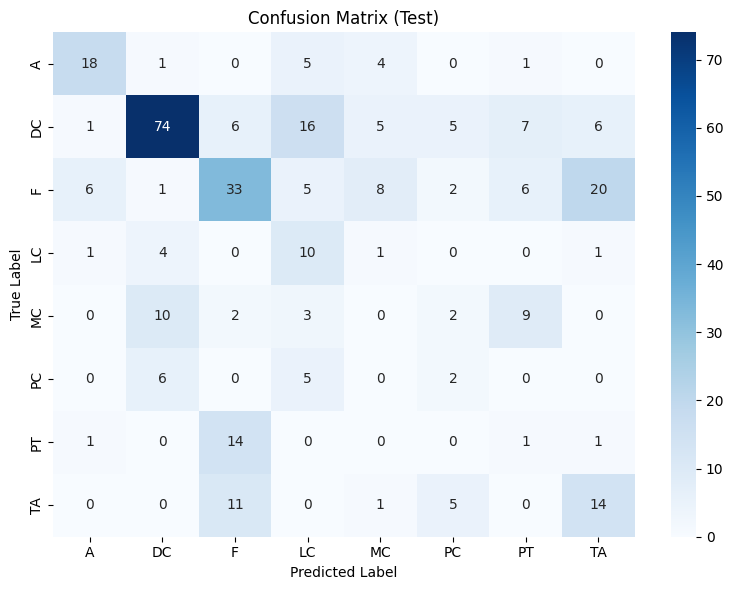

In [54]:
# Evaluate on validation and test splits with post-hoc class-bias calibration
val_true, val_pred_raw, val_logits = collect_logits_and_predictions(
    model, val_loader, device=DEVICE, desc="Val inference (raw)")

# Tune class bias on validation set to support hard minority classes.
class_bias, bias_meta = tune_class_bias_from_val(
    val_logits=val_logits,
    val_true=val_true,
    class_to_idx=class_to_idx,
    target_classes=("PT", "MC", "PC"),
    base_bias_grid=(0.0, 0.03, 0.06, 0.09, 0.12),
    pt_extra_grid=(0.0, 0.04, 0.08, 0.12, 0.16, 0.20),
    mc_extra_grid=(0.0, 0.03, 0.06, 0.09, 0.12),
    pc_extra_grid=(0.0, 0.03, 0.06, 0.09),
    key_classes=("TA", "PT", "PC", "MC"),
    acc_drop_tolerance=0.02,
)

val_true, val_pred, _ = collect_logits_and_predictions(
    model, val_loader, device=DEVICE, desc="Val inference (calibrated)", class_bias=class_bias)
test_true, test_pred, _ = collect_logits_and_predictions(
    model, test_loader, device=DEVICE, desc="Test inference (calibrated)", class_bias=class_bias)

val_macro_f1_all = f1_score(val_true, val_pred, average="macro", zero_division=0)
test_macro_f1_all = f1_score(test_true, test_pred, average="macro", zero_division=0)
val_acc = (val_true == val_pred).mean()
test_acc = (test_true == test_pred).mean()

present_test_classes = sorted(np.unique(test_true).tolist())
test_macro_f1_present = f1_score(
    test_true,
    test_pred,
    labels=present_test_classes,
    average="macro",
    zero_division=0,
)

print("Calibration meta:", bias_meta)
print("Applied class bias vector:", class_bias.tolist())
print(f"Validation -> Acc: {val_acc:.4f} | Macro F1 (all classes): {val_macro_f1_all:.4f}")
print(f"Test       -> Acc: {test_acc:.4f} | Macro F1 (all classes): {test_macro_f1_all:.4f}")
print(f"Test       -> Macro F1 (present classes only): {test_macro_f1_present:.4f}")

print("\nClasses present in test set:", [ordered_class_names[i] for i in present_test_classes])
print("\nClassification Report (Test):")
print(
    classification_report(
        test_true,
        test_pred,
        labels=list(range(len(ordered_class_names))),
        target_names=ordered_class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    test_true,
    test_pred,
    labels=list(range(len(ordered_class_names))),
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ordered_class_names,
    yticklabels=ordered_class_names,
)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()